# Models analyses

In [549]:
"""Import models."""
import pickle
from pathlib import Path

xgboost_model_path = Path("../models/xgboost_model.pkl")
logistic_regression_model_path = Path("../models/logistic_regression_model.pkl")

xgb_model = pickle.loads(xgboost_model_path.read_bytes())
logistic_regression_model = pickle.loads(logistic_regression_model_path.read_bytes())

print(f"Loaded XGBoost model from {xgboost_model_path}")
print(f"Loaded Logistic Regression model from {logistic_regression_model_path}")


Loaded XGBoost model from ../models/xgboost_model.pkl
Loaded Logistic Regression model from ../models/logistic_regression_model.pkl


In [550]:
"""Import test sets."""
import numpy as np
import pandas as pd

TESTING_PATH = "../data/prepared/tennis_testing.xlsx"
RAW_TESTING_PATH = "../data/testing/tennis_testing.xlsx"

test_set = pd.read_excel(TESTING_PATH)
raw_test_df = pd.read_excel(RAW_TESTING_PATH)

target = "y"
y_test = test_set[target]

print(f"Loaded prepared test set with {len(test_set)} rows")
print(f"Loaded raw test set with {len(raw_test_df)} rows")


Loaded prepared test set with 10924 rows
Loaded raw test set with 10924 rows


### Baselines

In [551]:
# Majority-class baseline: expected to be close to 50% after random player swapping.
baseline_accuracy = y_test.value_counts(normalize=True).max()
print("Majority class accuracy:", f"{baseline_accuracy:.2%}")

# Market baseline: Bet365 favorite wins when B365W < B365L.
odds = raw_test_df[["B365W", "B365L"]]
valid_odds = odds.gt(0).all(axis=1)
market_test_accuracy = (
    odds.loc[valid_odds, "B365W"] < odds.loc[valid_odds, "B365L"]
).mean()

print("Market test accuracy:", f"{market_test_accuracy:.2%}")
print("Valid odds:", f"{valid_odds.mean():.2%}")


Majority class accuracy: 50.06%
Market test accuracy: 66.39%
Valid odds: 99.62%


## Model Evaluation

In [552]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)


def get_model_data(model, test_set):
    # Use exactly the columns seen by the model during training.
    model_features = list(model.feature_names_in_)
    X = test_set[model_features]
    y = test_set["y"]
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return model_features, X, y, proba, pred


def evaluate_model(name, model, test_set):
    model_features, X, y, proba, pred = get_model_data(model, test_set)

    print(f"{name}")
    print("Accuracy:", f"{accuracy_score(y, pred):.2%}")
    print("Balanced accuracy:", f"{balanced_accuracy_score(y, pred):.2%}")
    print("Precision:", f"{precision_score(y, pred):.2%}")
    print("Recall:", f"{recall_score(y, pred):.2%}")
    print("F1:", f"{f1_score(y, pred):.2%}")
    print("ROC AUC:", f"{roc_auc_score(y, proba):.4f}")
    print("Log loss:", f"{log_loss(y, proba):.4f}")
    print("Brier score:", f"{brier_score_loss(y, proba):.4f}")
    print("Features:", len(model_features))
    print("Confusion matrix:")
    print(confusion_matrix(y, pred))

    return {
        "name": name,
        "features": model_features,
        "X": X,
        "y": y,
        "proba": proba,
        "pred": pred,
    }


xgb_results = evaluate_model("XGBoost", xgb_model, test_set)
logreg_results = evaluate_model("Logistic Regression", logistic_regression_model, test_set)

agreement = (xgb_results["pred"] == logreg_results["pred"]).mean()
prob_corr = pd.Series(xgb_results["proba"]).corr(pd.Series(logreg_results["proba"]))

print(f"Model agreement: {agreement:.2%}")
print(f"Probability correlation: {prob_corr:.4f}")


XGBoost
Accuracy: 67.74%
Balanced accuracy: 67.74%
Precision: 67.86%
Recall: 67.56%
F1: 67.71%
ROC AUC: 0.7471
Log loss: 0.5906
Brier score: 0.2034
Features: 18
Confusion matrix:
[[3705 1750]
 [1774 3695]]
Logistic Regression
Accuracy: 67.79%
Balanced accuracy: 67.79%
Precision: 68.07%
Recall: 67.16%
F1: 67.61%
ROC AUC: 0.7474
Log loss: 0.5904
Brier score: 0.2034
Features: 18
Confusion matrix:
[[3732 1723]
 [1796 3673]]
Model agreement: 98.95%
Probability correlation: 0.9980


## Feature Usage

In [553]:
def source_feature_name(transformed_name, model_features):
    # Map transformed one-hot and missing-indicator names back to source columns.
    if transformed_name.startswith("num__missingindicator_"):
        return transformed_name.removeprefix("num__missingindicator_")
    if transformed_name.startswith("num__"):
        return transformed_name.removeprefix("num__")
    if transformed_name.startswith("cat__"):
        encoded = transformed_name.removeprefix("cat__")
    elif transformed_name.startswith("high_cardinality__"):
        encoded = transformed_name.removeprefix("high_cardinality__")
    else:
        return transformed_name

    for feature in model_features:
        if encoded.startswith(f"{feature}_"):
            return feature
    return encoded


def feature_usage(name, model, top_n=15):
    model_features = list(model.feature_names_in_)
    transformed_names = model[:-1].get_feature_names_out()
    estimator = model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        column = "Importance"
    else:
        values = np.abs(estimator.coef_[0])
        column = "Abs_Coefficient"

    usage = pd.DataFrame({"Feature": transformed_names, column: values})
    usage["Source_Feature"] = usage["Feature"].map(
        lambda feature: source_feature_name(feature, model_features)
    )

    usage_by_source = (
        usage.groupby("Source_Feature", as_index=False)[column]
        .sum()
        .sort_values(column, ascending=False)
    )

    print(f"{name} feature usage")
    display(usage_by_source.head(top_n))


feature_usage("XGBoost", xgb_model)
feature_usage("Logistic Regression", logistic_regression_model)


XGBoost feature usage


,Source_Feature,Importance
8,Odds_Diff,0.554704
16,Surface_Elo_Diff,0.179429
3,Elo_Diff,0.120697
14,Series,0.021473
15,Surface,0.015756
4,Elo_Diff_x_EarlyRound,0.015162
0,Best_of_5,0.013291
17,Tournament,0.012737
9,Points_Diff,0.011777
12,Recent_Surface_Form_Diff,0.011736


Logistic Regression feature usage


,Source_Feature,Abs_Coefficient
8,Odds_Diff,1.161597
12,Recent_Surface_Form_Diff,0.035872
2,Dominance_Form_Diff,0.025886
4,Elo_Diff_x_EarlyRound,0.022303
10,Rank_Diff,0.020121
7,H2H_Surface_Diff,0.004650
0,Best_of_5,0.001619
16,Surface_Elo_Diff,0.000719
15,Surface,0.000000
14,Series,0.000000


## Most Confident Wrong Matches

In [554]:
def show_most_wrong(name, results, test_set, top_n=10):
    # Show confident errors: high confidence, wrong class.
    rows = pd.DataFrame({
        "Actual_Result": results["y"],
        "Predicted_Class": results["pred"].astype(int),
        "Prob_Player_1_Wins": results["proba"],
    }, index=test_set.index)

    rows["Actual_Winner"] = np.where(
        rows["Actual_Result"] == 1,
        test_set["Player_1"],
        test_set["Player_2"],
    )
    rows["Predicted_Winner"] = np.where(
        rows["Predicted_Class"] == 1,
        test_set["Player_1"],
        test_set["Player_2"],
    )
    rows["Confidence"] = np.where(
        rows["Predicted_Class"] == 1,
        rows["Prob_Player_1_Wins"],
        1 - rows["Prob_Player_1_Wins"],
    )

    detail_columns = [
        "Date", "Player_1", "Player_2", "Series", "Surface", "Round",
        "Odds_Diff", "Elo_Diff", "Surface_Elo_Diff", "Rank_Diff", "Points_Diff",
    ]
    detail_columns = [column for column in detail_columns if column in test_set.columns]

    wrong = rows[rows["Actual_Result"] != rows["Predicted_Class"]]
    wrong = wrong.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident wrong matches")
    display(wrong.join(test_set[detail_columns]))


show_most_wrong("XGBoost", xgb_results, test_set)
show_most_wrong("Logistic Regression", logreg_results, test_set)


XGBoost: most confident wrong matches


,Actual_Result,Predicted_Class,Prob_Player_1_Wins,Actual_Winner,Predicted_Winner,Confidence,Date,Player_1,Player_2,Series,Surface,Round,Odds_Diff,Elo_Diff,Surface_Elo_Diff,Rank_Diff,Points_Diff
4795,1,0,0.042403,Nardi L.,Djokovic N.,0.957597,2024-03-12,Nardi L.,Djokovic N.,Masters 1000,Hard,3rd Round,-2.803655,-420.252662,-382.373275,122.0,-8336.4
2583,1,0,0.044427,Marozsan F.,Alcaraz C.,0.955573,2023-05-15,Marozsan F.,Alcaraz C.,Masters 1000,Clay,3rd Round,-3.125544,-419.159403,-361.887167,133.0,-6329.0
2712,1,0,0.045059,Seyboth Wild T.,Medvedev D.,0.954942,2023-05-30,Seyboth Wild T.,Medvedev D.,Grand Slam,Clay,1st Round,-2.349105,-420.252662,-325.482005,170.0,-5981.0
5307,1,0,0.052639,Tabilo A.,Djokovic N.,0.947361,2024-05-12,Tabilo A.,Djokovic N.,Masters 1000,Clay,3rd Round,-2.129566,-420.252662,-382.373275,31.0,-8336.4
9913,1,0,0.055276,Kypson P.,De Minaur A.,0.944724,2026-02-24,Kypson P.,De Minaur A.,ATP500,Hard,1st Round,-2.244316,-416.179659,-382.373275,97.0,-3670.0
9167,1,0,0.055616,Griekspoor T.,Sinner J.,0.944384,2025-10-05,Griekspoor T.,Sinner J.,Masters 1000,Hard,3rd Round,-2.924636,-333.774442,-348.283122,29.0,-8336.4
4669,1,0,0.055945,Altmaier D.,Zverev A.,0.944055,2024-02-28,Altmaier D.,Zverev A.,ATP500,Hard,1st Round,-2.244316,-375.845320,-380.480624,51.0,-4164.0
6304,0,1,0.943416,Van De Zandschulp B.,Alcaraz C.,0.943416,2024-08-30,Alcaraz C.,Van De Zandschulp B.,Grand Slam,Hard,2nd Round,3.357345,391.152865,322.279233,-71.0,6621.0
10712,0,1,0.942678,Cerundolo J.M.,Sinner J.,0.942678,2026-05-28,Sinner J.,Cerundolo J.M.,Grand Slam,Clay,2nd Round,3.248146,423.496681,386.955338,-55.0,8300.5
5726,0,1,0.942576,Comesana F.,Rublev A.,0.942576,2024-07-02,Rublev A.,Comesana F.,Grand Slam,Grass,1st Round,2.803655,370.635967,229.997566,-116.0,3891.0


Logistic Regression: most confident wrong matches


,Actual_Result,Predicted_Class,Prob_Player_1_Wins,Actual_Winner,Predicted_Winner,Confidence,Date,Player_1,Player_2,Series,Surface,Round,Odds_Diff,Elo_Diff,Surface_Elo_Diff,Rank_Diff,Points_Diff
6304,0,1,0.971950,Van De Zandschulp B.,Alcaraz C.,0.971950,2024-08-30,Alcaraz C.,Van De Zandschulp B.,Grand Slam,Hard,2nd Round,3.357345,391.152865,322.279233,-71.0,6621.0
10712,0,1,0.967434,Cerundolo J.M.,Sinner J.,0.967434,2026-05-28,Sinner J.,Cerundolo J.M.,Grand Slam,Clay,2nd Round,3.248146,423.496681,386.955338,-55.0,8300.5
2583,1,0,0.034031,Marozsan F.,Alcaraz C.,0.965969,2023-05-15,Marozsan F.,Alcaraz C.,Masters 1000,Clay,3rd Round,-3.125544,-419.159403,-361.887167,133.0,-6329.0
9167,1,0,0.043973,Griekspoor T.,Sinner J.,0.956027,2025-10-05,Griekspoor T.,Sinner J.,Masters 1000,Hard,3rd Round,-2.924636,-333.774442,-348.283122,29.0,-8336.4
4795,1,0,0.047839,Nardi L.,Djokovic N.,0.952161,2024-03-12,Nardi L.,Djokovic N.,Masters 1000,Hard,3rd Round,-2.803655,-420.252662,-382.373275,122.0,-8336.4
5726,0,1,0.951601,Comesana F.,Rublev A.,0.951601,2024-07-02,Rublev A.,Comesana F.,Grand Slam,Grass,1st Round,2.803655,370.635967,229.997566,-116.0,3891.0
7516,1,0,0.052930,Goffin D.,Alcaraz C.,0.947070,2025-03-22,Goffin D.,Alcaraz C.,Masters 1000,Hard,2nd Round,-2.678491,-337.048905,-278.882978,52.0,-5907.0
844,1,0,0.060151,Holt B.,Fritz T.,0.939849,2022-08-29,Holt B.,Fritz T.,Grand Slam,Hard,1st Round,-2.525729,-234.340856,-226.549573,291.0,-2928.0
7347,1,0,0.060276,Pacheco Mendez R.,Ruud C.,0.939724,2025-02-27,Pacheco Mendez R.,Ruud C.,ATP500,Hard,2nd Round,-2.525729,-305.514668,-217.672599,351.0,-4183.0
32,0,1,0.933688,Simon G.,Carreno Busta P.,0.933688,2022-05-24,Carreno Busta P.,Simon G.,Grand Slam,Clay,1st Round,2.525729,154.397592,140.065281,-140.0,1744.0


## Calibration Curves

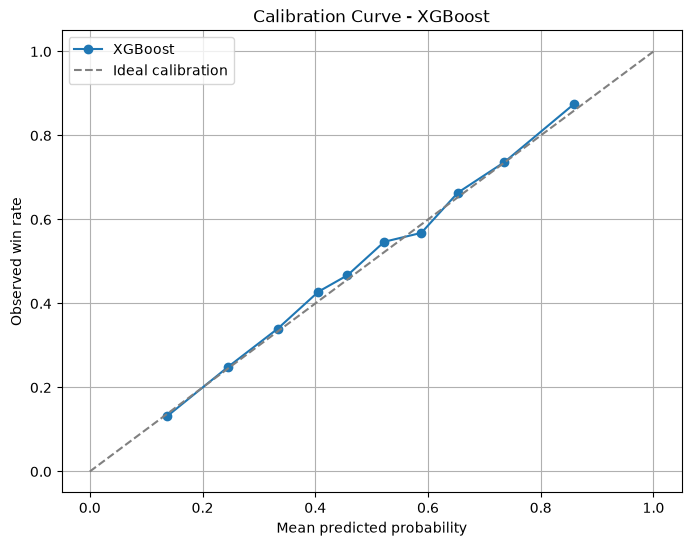

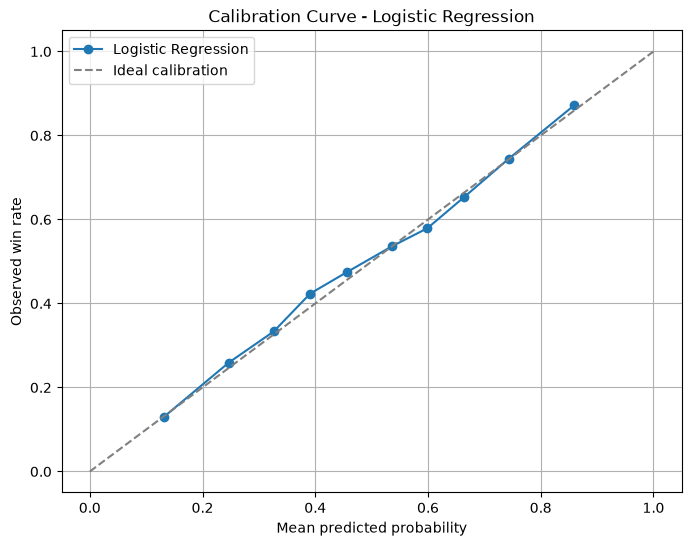

In [555]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt


def plot_calibration_curve(results, model_name, n_bins=10):
    # Standard calibration curve for probability that Player 1 wins.
    prob_true, prob_pred = calibration_curve(
        results["y"],
        results["proba"],
        n_bins=n_bins,
        strategy="quantile",
    )

    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, marker="o", label=model_name)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ideal calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed win rate")
    plt.title(f"Calibration Curve - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_calibration_curve(xgb_results, "XGBoost")
plot_calibration_curve(logreg_results, "Logistic Regression")


## Confidence Calibration

XGBoost: confidence calibration


,confidence_bin,matches,avg_confidence,observed_accuracy,wrong_predictions,confidence_gap
0,"(0.499, 0.537]",1093,0.516595,0.537969,505,-0.021374
1,"(0.537, 0.562]",1093,0.545908,0.540714,502,0.005194
2,"(0.562, 0.594]",1091,0.580765,0.554537,486,0.026227
3,"(0.594, 0.618]",1098,0.603997,0.584699,456,0.019297
4,"(0.618, 0.66]",1087,0.639101,0.642134,389,-0.003033
5,"(0.66, 0.7]",1092,0.680638,0.700549,327,-0.019911
6,"(0.7, 0.738]",1093,0.717592,0.719122,307,-0.001530
7,"(0.738, 0.797]",1092,0.773497,0.750916,272,0.022581
8,"(0.797, 0.845]",1092,0.816873,0.827839,188,-0.010966
9,"(0.845, 0.96]",1093,0.905521,0.915828,92,-0.010307


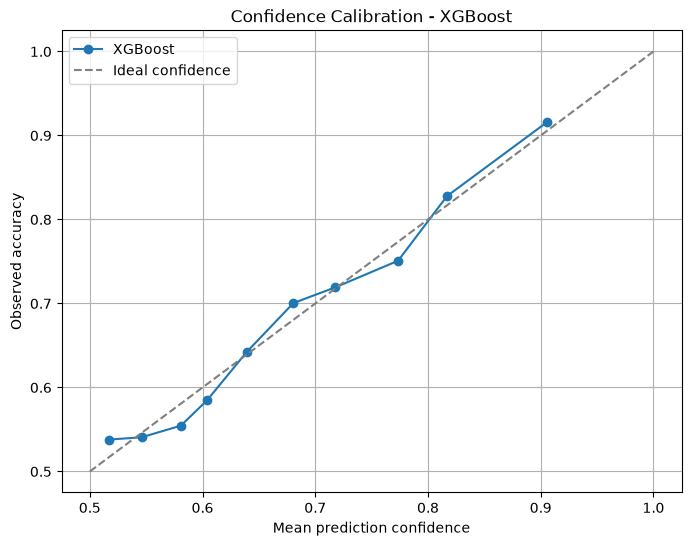

XGBoost: most confident wrong predictions


,y_true,proba_player_1,pred,confidence,is_correct,is_wrong,confidence_bin,Date,Player_1,Player_2,Series,Surface,Round,Odds_Diff,Elo_Diff,Surface_Elo_Diff,Rank_Diff,Points_Diff
4795,1,0.042403,0,0.957597,False,True,"(0.845, 0.96]",2024-03-12,Nardi L.,Djokovic N.,Masters 1000,Hard,3rd Round,-2.803655,-420.252662,-382.373275,122.0,-8336.4
2583,1,0.044427,0,0.955573,False,True,"(0.845, 0.96]",2023-05-15,Marozsan F.,Alcaraz C.,Masters 1000,Clay,3rd Round,-3.125544,-419.159403,-361.887167,133.0,-6329.0
2712,1,0.045059,0,0.954942,False,True,"(0.845, 0.96]",2023-05-30,Seyboth Wild T.,Medvedev D.,Grand Slam,Clay,1st Round,-2.349105,-420.252662,-325.482005,170.0,-5981.0
5307,1,0.052639,0,0.947361,False,True,"(0.845, 0.96]",2024-05-12,Tabilo A.,Djokovic N.,Masters 1000,Clay,3rd Round,-2.129566,-420.252662,-382.373275,31.0,-8336.4
9913,1,0.055276,0,0.944724,False,True,"(0.845, 0.96]",2026-02-24,Kypson P.,De Minaur A.,ATP500,Hard,1st Round,-2.244316,-416.179659,-382.373275,97.0,-3670.0
9167,1,0.055616,0,0.944384,False,True,"(0.845, 0.96]",2025-10-05,Griekspoor T.,Sinner J.,Masters 1000,Hard,3rd Round,-2.924636,-333.774442,-348.283122,29.0,-8336.4
4669,1,0.055945,0,0.944055,False,True,"(0.845, 0.96]",2024-02-28,Altmaier D.,Zverev A.,ATP500,Hard,1st Round,-2.244316,-375.845320,-380.480624,51.0,-4164.0
6304,0,0.943416,1,0.943416,False,True,"(0.845, 0.96]",2024-08-30,Alcaraz C.,Van De Zandschulp B.,Grand Slam,Hard,2nd Round,3.357345,391.152865,322.279233,-71.0,6621.0
10712,0,0.942678,1,0.942678,False,True,"(0.845, 0.96]",2026-05-28,Sinner J.,Cerundolo J.M.,Grand Slam,Clay,2nd Round,3.248146,423.496681,386.955338,-55.0,8300.5
5726,0,0.942576,1,0.942576,False,True,"(0.845, 0.96]",2024-07-02,Rublev A.,Comesana F.,Grand Slam,Grass,1st Round,2.803655,370.635967,229.997566,-116.0,3891.0


Logistic Regression: confidence calibration


,confidence_bin,matches,avg_confidence,observed_accuracy,wrong_predictions,confidence_gap
0,"(0.499, 0.542]",1093,0.521680,0.538884,504,-0.017204
1,"(0.542, 0.574]",1092,0.558028,0.541209,501,0.016819
2,"(0.574, 0.604]",1092,0.588793,0.559524,481,0.029269
3,"(0.604, 0.635]",1093,0.619035,0.590119,448,0.028916
4,"(0.635, 0.668]",1092,0.652212,0.630037,404,0.022175
5,"(0.668, 0.707]",1092,0.686249,0.700549,327,-0.014301
6,"(0.707, 0.746]",1093,0.726536,0.720037,306,0.006500
7,"(0.746, 0.795]",1092,0.770133,0.754579,268,0.015554
8,"(0.795, 0.853]",1092,0.820824,0.829670,186,-0.008846
9,"(0.853, 0.988]",1093,0.906816,0.913998,94,-0.007182


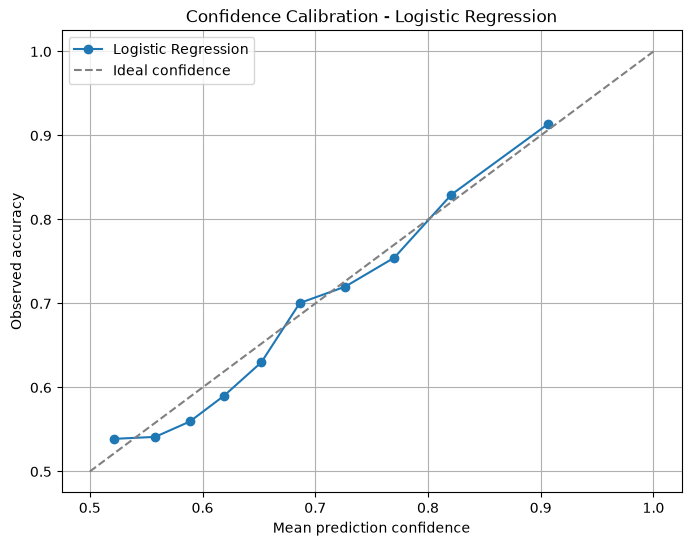

Logistic Regression: most confident wrong predictions


,y_true,proba_player_1,pred,confidence,is_correct,is_wrong,confidence_bin,Date,Player_1,Player_2,Series,Surface,Round,Odds_Diff,Elo_Diff,Surface_Elo_Diff,Rank_Diff,Points_Diff
6304,0,0.971950,1,0.971950,False,True,"(0.853, 0.988]",2024-08-30,Alcaraz C.,Van De Zandschulp B.,Grand Slam,Hard,2nd Round,3.357345,391.152865,322.279233,-71.0,6621.0
10712,0,0.967434,1,0.967434,False,True,"(0.853, 0.988]",2026-05-28,Sinner J.,Cerundolo J.M.,Grand Slam,Clay,2nd Round,3.248146,423.496681,386.955338,-55.0,8300.5
2583,1,0.034031,0,0.965969,False,True,"(0.853, 0.988]",2023-05-15,Marozsan F.,Alcaraz C.,Masters 1000,Clay,3rd Round,-3.125544,-419.159403,-361.887167,133.0,-6329.0
9167,1,0.043973,0,0.956027,False,True,"(0.853, 0.988]",2025-10-05,Griekspoor T.,Sinner J.,Masters 1000,Hard,3rd Round,-2.924636,-333.774442,-348.283122,29.0,-8336.4
4795,1,0.047839,0,0.952161,False,True,"(0.853, 0.988]",2024-03-12,Nardi L.,Djokovic N.,Masters 1000,Hard,3rd Round,-2.803655,-420.252662,-382.373275,122.0,-8336.4
5726,0,0.951601,1,0.951601,False,True,"(0.853, 0.988]",2024-07-02,Rublev A.,Comesana F.,Grand Slam,Grass,1st Round,2.803655,370.635967,229.997566,-116.0,3891.0
7516,1,0.052930,0,0.947070,False,True,"(0.853, 0.988]",2025-03-22,Goffin D.,Alcaraz C.,Masters 1000,Hard,2nd Round,-2.678491,-337.048905,-278.882978,52.0,-5907.0
844,1,0.060151,0,0.939849,False,True,"(0.853, 0.988]",2022-08-29,Holt B.,Fritz T.,Grand Slam,Hard,1st Round,-2.525729,-234.340856,-226.549573,291.0,-2928.0
7347,1,0.060276,0,0.939724,False,True,"(0.853, 0.988]",2025-02-27,Pacheco Mendez R.,Ruud C.,ATP500,Hard,2nd Round,-2.525729,-305.514668,-217.672599,351.0,-4183.0
32,0,0.933688,1,0.933688,False,True,"(0.853, 0.988]",2022-05-24,Carreno Busta P.,Simon G.,Grand Slam,Clay,1st Round,2.525729,154.397592,140.065281,-140.0,1744.0


In [556]:
def confidence_calibration_analysis(name, results, test_set, n_bins=10, top_n=10):
    # Confidence is the probability assigned to the predicted class.
    analysis = pd.DataFrame({
        "y_true": results["y"].to_numpy(),
        "proba_player_1": results["proba"],
        "pred": results["pred"].astype(int),
    }, index=test_set.index)

    analysis["confidence"] = np.where(
        analysis["pred"] == 1,
        analysis["proba_player_1"],
        1 - analysis["proba_player_1"],
    )
    analysis["is_correct"] = analysis["pred"] == analysis["y_true"]
    analysis["is_wrong"] = ~analysis["is_correct"]

    # Quantile bins keep a similar number of matches in each bin.
    analysis["confidence_bin"] = pd.qcut(
        analysis["confidence"],
        q=n_bins,
        duplicates="drop",
    )

    calibration_by_confidence = (
        analysis
        .groupby("confidence_bin", observed=True)
        .agg(
            matches=("is_correct", "size"),
            avg_confidence=("confidence", "mean"),
            observed_accuracy=("is_correct", "mean"),
            wrong_predictions=("is_wrong", "sum"),
        )
        .reset_index()
    )
    calibration_by_confidence["confidence_gap"] = (
        calibration_by_confidence["avg_confidence"]
        - calibration_by_confidence["observed_accuracy"]
    )

    print(f"{name}: confidence calibration")
    display(calibration_by_confidence)

    plt.figure(figsize=(8, 6))
    plt.plot(
        calibration_by_confidence["avg_confidence"],
        calibration_by_confidence["observed_accuracy"],
        marker="o",
        label=name,
    )
    plt.plot([0.5, 1.0], [0.5, 1.0], linestyle="--", color="gray", label="Ideal confidence")
    plt.xlabel("Mean prediction confidence")
    plt.ylabel("Observed accuracy")
    plt.title(f"Confidence Calibration - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    detail_columns = [
        "Date", "Player_1", "Player_2", "Series", "Surface", "Round",
        "Odds_Diff", "Elo_Diff", "Surface_Elo_Diff", "Rank_Diff", "Points_Diff",
    ]
    detail_columns = [column for column in detail_columns if column in test_set.columns]

    confident_wrong = (
        analysis[analysis["is_wrong"]]
        .sort_values("confidence", ascending=False)
        .head(top_n)
        .join(test_set[detail_columns])
    )

    print(f"{name}: most confident wrong predictions")
    display(confident_wrong)


confidence_calibration_analysis("XGBoost", xgb_results, test_set)
confidence_calibration_analysis("Logistic Regression", logreg_results, test_set)


## High-Confidence Segment

In [557]:
def high_confidence_segment_analysis(name, results, test_set, threshold=0.85):
    # Analyze only predictions where the model is very confident.
    segment = pd.DataFrame({
        "y_true": results["y"].to_numpy(),
        "proba_player_1": results["proba"],
        "y_pred": results["pred"].astype(int),
    }, index=test_set.index)

    segment["confidence"] = np.where(
        segment["y_pred"] == 1,
        segment["proba_player_1"],
        1 - segment["proba_player_1"],
    )
    segment["is_correct"] = segment["y_pred"] == segment["y_true"]

    high_confidence = segment[segment["confidence"] >= threshold].copy()

    print(f"{name}: high-confidence predictions")
    print("Threshold:", f"{threshold:.0%}")
    print("Matches:", len(high_confidence))
    print("Accuracy:", f"{high_confidence['is_correct'].mean():.2%}")
    print("Error rate:", f"{1 - high_confidence['is_correct'].mean():.2%}")

    # If an explicit experience feature exists, use it. Otherwise use rank gap.
    if "Min_Experience" in test_set.columns:
        segment_feature = "Min_Experience"
        high_confidence[segment_feature] = test_set.loc[high_confidence.index, segment_feature]
        low_label = "low experience"
        high_label = "high experience"
    elif "Rank_Diff" in test_set.columns:
        segment_feature = "Abs_Rank_Diff"
        high_confidence[segment_feature] = test_set.loc[high_confidence.index, "Rank_Diff"].abs()
        low_label = "smaller rank gap"
        high_label = "larger rank gap"
    else:
        display(high_confidence.sort_values("confidence", ascending=False).head(10))
        return high_confidence

    median_value = high_confidence[segment_feature].median()
    low_segment = high_confidence[high_confidence[segment_feature] < median_value]
    high_segment = high_confidence[high_confidence[segment_feature] >= median_value]

    comparison = pd.DataFrame({
        "segment": [low_label, high_label],
        "matches": [len(low_segment), len(high_segment)],
        "avg_confidence": [low_segment["confidence"].mean(), high_segment["confidence"].mean()],
        "observed_accuracy": [low_segment["is_correct"].mean(), high_segment["is_correct"].mean()],
        "error_rate": [1 - low_segment["is_correct"].mean(), 1 - high_segment["is_correct"].mean()],
    })

    print(f"Split feature: {segment_feature}")
    display(comparison)

    detail_columns = [
        "Date", "Player_1", "Player_2", "Series", "Surface", "Round",
        "Odds_Diff", "Elo_Diff", "Surface_Elo_Diff", "Rank_Diff", "Points_Diff",
    ]
    detail_columns = [column for column in detail_columns if column in test_set.columns]

    print(f"{name}: wrong high-confidence examples")
    display(
        high_confidence[~high_confidence["is_correct"]]
        .sort_values("confidence", ascending=False)
        .head(10)
        .join(test_set[detail_columns])
    )

    return high_confidence


xgb_high_confidence = high_confidence_segment_analysis("XGBoost", xgb_results, test_set)
logreg_high_confidence = high_confidence_segment_analysis("Logistic Regression", logreg_results, test_set)


XGBoost: high-confidence predictions
Threshold: 85%
Matches: 1031
Accuracy: 91.95%
Error rate: 8.05%
Split feature: Abs_Rank_Diff


,segment,matches,avg_confidence,observed_accuracy,error_rate
0,smaller rank gap,505,0.906447,0.920792,0.079208
1,larger rank gap,519,0.911466,0.917148,0.082852


XGBoost: wrong high-confidence examples


,y_true,proba_player_1,y_pred,confidence,is_correct,Abs_Rank_Diff,Date,Player_1,Player_2,Series,Surface,Round,Odds_Diff,Elo_Diff,Surface_Elo_Diff,Rank_Diff,Points_Diff
4795,1,0.042403,0,0.957597,False,122.0,2024-03-12,Nardi L.,Djokovic N.,Masters 1000,Hard,3rd Round,-2.803655,-420.252662,-382.373275,122.0,-8336.4
2583,1,0.044427,0,0.955573,False,133.0,2023-05-15,Marozsan F.,Alcaraz C.,Masters 1000,Clay,3rd Round,-3.125544,-419.159403,-361.887167,133.0,-6329.0
2712,1,0.045059,0,0.954942,False,170.0,2023-05-30,Seyboth Wild T.,Medvedev D.,Grand Slam,Clay,1st Round,-2.349105,-420.252662,-325.482005,170.0,-5981.0
5307,1,0.052639,0,0.947361,False,31.0,2024-05-12,Tabilo A.,Djokovic N.,Masters 1000,Clay,3rd Round,-2.129566,-420.252662,-382.373275,31.0,-8336.4
9913,1,0.055276,0,0.944724,False,97.0,2026-02-24,Kypson P.,De Minaur A.,ATP500,Hard,1st Round,-2.244316,-416.179659,-382.373275,97.0,-3670.0
9167,1,0.055616,0,0.944384,False,29.0,2025-10-05,Griekspoor T.,Sinner J.,Masters 1000,Hard,3rd Round,-2.924636,-333.774442,-348.283122,29.0,-8336.4
4669,1,0.055945,0,0.944055,False,51.0,2024-02-28,Altmaier D.,Zverev A.,ATP500,Hard,1st Round,-2.244316,-375.845320,-380.480624,51.0,-4164.0
6304,0,0.943416,1,0.943416,False,71.0,2024-08-30,Alcaraz C.,Van De Zandschulp B.,Grand Slam,Hard,2nd Round,3.357345,391.152865,322.279233,-71.0,6621.0
10712,0,0.942678,1,0.942678,False,55.0,2026-05-28,Sinner J.,Cerundolo J.M.,Grand Slam,Clay,2nd Round,3.248146,423.496681,386.955338,-55.0,8300.5
5726,0,0.942576,1,0.942576,False,116.0,2024-07-02,Rublev A.,Comesana F.,Grand Slam,Grass,1st Round,2.803655,370.635967,229.997566,-116.0,3891.0


Logistic Regression: high-confidence predictions
Threshold: 85%
Matches: 1140
Accuracy: 91.40%
Error rate: 8.60%
Split feature: Abs_Rank_Diff


,segment,matches,avg_confidence,observed_accuracy,error_rate
0,smaller rank gap,564,0.899517,0.923759,0.076241
1,larger rank gap,569,0.909041,0.903339,0.096661


Logistic Regression: wrong high-confidence examples


,y_true,proba_player_1,y_pred,confidence,is_correct,Abs_Rank_Diff,Date,Player_1,Player_2,Series,Surface,Round,Odds_Diff,Elo_Diff,Surface_Elo_Diff,Rank_Diff,Points_Diff
6304,0,0.971950,1,0.971950,False,71.0,2024-08-30,Alcaraz C.,Van De Zandschulp B.,Grand Slam,Hard,2nd Round,3.357345,391.152865,322.279233,-71.0,6621.0
10712,0,0.967434,1,0.967434,False,55.0,2026-05-28,Sinner J.,Cerundolo J.M.,Grand Slam,Clay,2nd Round,3.248146,423.496681,386.955338,-55.0,8300.5
2583,1,0.034031,0,0.965969,False,133.0,2023-05-15,Marozsan F.,Alcaraz C.,Masters 1000,Clay,3rd Round,-3.125544,-419.159403,-361.887167,133.0,-6329.0
9167,1,0.043973,0,0.956027,False,29.0,2025-10-05,Griekspoor T.,Sinner J.,Masters 1000,Hard,3rd Round,-2.924636,-333.774442,-348.283122,29.0,-8336.4
4795,1,0.047839,0,0.952161,False,122.0,2024-03-12,Nardi L.,Djokovic N.,Masters 1000,Hard,3rd Round,-2.803655,-420.252662,-382.373275,122.0,-8336.4
5726,0,0.951601,1,0.951601,False,116.0,2024-07-02,Rublev A.,Comesana F.,Grand Slam,Grass,1st Round,2.803655,370.635967,229.997566,-116.0,3891.0
7516,1,0.052930,0,0.947070,False,52.0,2025-03-22,Goffin D.,Alcaraz C.,Masters 1000,Hard,2nd Round,-2.678491,-337.048905,-278.882978,52.0,-5907.0
844,1,0.060151,0,0.939849,False,291.0,2022-08-29,Holt B.,Fritz T.,Grand Slam,Hard,1st Round,-2.525729,-234.340856,-226.549573,291.0,-2928.0
7347,1,0.060276,0,0.939724,False,351.0,2025-02-27,Pacheco Mendez R.,Ruud C.,ATP500,Hard,2nd Round,-2.525729,-305.514668,-217.672599,351.0,-4183.0
32,0,0.933688,1,0.933688,False,140.0,2022-05-24,Carreno Busta P.,Simon G.,Grand Slam,Clay,1st Round,2.525729,154.397592,140.065281,-140.0,1744.0
